# Mathematica-Style Equilibrium Panel

Produces a 2×2 composite panel for the Baseline model, matching the visual
style of `graphtest-money.nb` (purple/orange colour scheme, percentage tick
labels, Mathematica-style layout).

**Requires:** `PKAssetPrices`, `CairoMakie`

In [ ]:
using PKAssetPrices
using PKAssetPrices.Static: solve_model, eval_curve
using CairoMakie
using Printf

# ── Colour palette (Mathematica graphtest-money.nb) ──
const CURVE_COLOR  = RGBf(0.5, 0.0, 0.5)    # purple  – IS, AD, asset demand
const SUPPLY_COLOR = RGBf(1.0, 0.5, 0.0)    # orange  – IR, AS, asset supply
const COUNTERFACT  = (CURVE_COLOR, 0.38)     # faded purple – counterfactual

# Balance-sheet palette
const BS_ASSET     = CURVE_COLOR  # purple – assets
const BS_LIABILITY = SUPPLY_COLOR # orange – liabilities

const PLOT_RANGES = (
    IS_IR_X = (4.0, 10.0),
    IS_IR_Y = (0.06, 0.15),
    AD_AS_X = (5.5, 8.5),
    AD_AS_Y = (1.2, 2.2),
    AM_X    = (0.6, 1.3),
    AM_Y    = (0.7, 1.3),
)

FONT_SIZE   = 20
TITLE_SIZE  = 26
LEGEND_SIZE = 20

20

In [2]:
# ── 1. Solve model ─────────────────────────────────────────────────────
solution = solve_model(PKAssetPrices.Static.Baseline)
vars     = solution.variables

Y_eq   = vars[:Y]
r_eq   = vars[:r]
P_eq   = vars[:P]
AP_eq  = vars[:AP]
dL_val = vars[:dL]
dM_val = vars[:dM]
dR_val = vars[:dR]

println("Baseline model solved.")
println("  Y  = $(round(Y_eq, sigdigits=5))")
println("  r  = $(round(r_eq, sigdigits=5))")
println("  P  = $(round(P_eq, sigdigits=5))")
println("  AP = $(round(AP_eq, sigdigits=5))")

Baseline model solved.
  Y  = 6.566
  r  = 0.11203
  P  = 1.7483
  AP = 0.99656


In [3]:
# ── 2. Build figure ─────────────────────────────────────────────────────
fig = Figure(
    size = (1400, 1000),
    fontsize = FONT_SIZE,
    figure_padding = (28, 38, 28, 28),
    backgroundcolor = :white,
)

# ── Panel A: Goods Market Dynamics (IS/IR) ───────────────────────────
ax1 = Axis(
    fig[1, 1];
    title = "(A) Goods Market Dynamics",
    xlabel = "Output Y",
    ylabel = "interest rate r",
    xgridcolor = (:black, 0.12),
    ygridcolor = (:black, 0.12),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)

# IS curve: r → Y
r_range = range(PLOT_RANGES.IS_IR_Y...; length = 200)
is_Y = map(r_range) do r
    v = copy(vars); v[:r] = r
    eval_curve(solution.model, v).IS
end
lines!(ax1, is_Y, r_range; color = SUPPLY_COLOR, linewidth = 3, label = "IS")

# IR curve: Y → r
y_range1 = range(PLOT_RANGES.IS_IR_X...; length = 200)
ir_r = map(y_range1) do y
    v = copy(vars); v[:Y] = y
    eval_curve(solution.model, v).IR
end
lines!(ax1, y_range1, ir_r; color = CURVE_COLOR, linewidth = 3, label = "IR")

# Counterfactual IR (lower i₀)
lower_model = PKAssetPrices.Static.Parametrization(
    solution.model.model,
    merge(copy(solution.model.params), Dict(:i0 => 0.0)),
    copy(solution.model.u0),
)
lower_ir_r = map(y_range1) do y
    v = copy(vars); v[:Y] = y
    eval_curve(lower_model, v).IR
end
lines!(ax1, y_range1, lower_ir_r;
    color = CURVE_COLOR, linewidth = 3, linestyle = :dash,
    label = "IR (lower i₀)")

xlims!(ax1, PLOT_RANGES.IS_IR_X...)
ylims!(ax1, PLOT_RANGES.IS_IR_Y...)
# Inline labels (no legend box) — relative coordinates guarantee inside chart
text!(ax1, 6.6, 0.14; text = "IS", space = :data,
    color = SUPPLY_COLOR, fontsize = LEGEND_SIZE, align = (:right, :top))
text!(ax1, 9.5, 0.139; text = "IR", space = :data,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:center, :top))
text!(ax1, 9.3, 0.11; text = "IR (lower i₀)", space = :data,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:center, :top))
ax1

Axis with 6 plots:
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


In [4]:
# display(fig)

In [5]:
# ── Panel B: Output and Inflation Dynamics (AD/AS) ──────────────────
ax2 = Axis(
    fig[1, 2];
    title = "(B) Output and Inflation Dynamics",
    xlabel = "Output Y",
    ylabel = "Price Level P",
    xgridcolor = (:black, 0.12),
    ygridcolor = (:black, 0.12),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)

# AD curve: P → Y
p_range = range(PLOT_RANGES.AD_AS_Y...; length = 200)
ad_Y = map(p_range) do p
    v = copy(vars); v[:P] = p
    eval_curve(solution.model, v).ADc
end
lines!(ax2, ad_Y, p_range; color = CURVE_COLOR, linewidth = 3, label = "AD")

# AS curve: Y → P
y_range2 = range(PLOT_RANGES.AD_AS_X...; length = 200)
as_P = map(y_range2) do y
    v = copy(vars); v[:Y] = y
    eval_curve(solution.model, v).ASc
end
lines!(ax2, y_range2, as_P; color = SUPPLY_COLOR, linewidth = 3, label = "AS")

# AD counterfactual (lower i₀)
lower_ad_Y = map(p_range) do p
    v = copy(vars); v[:P] = p
    eval_curve(lower_model, v).ADc
end
lines!(ax2, lower_ad_Y, p_range;
    color = (CURVE_COLOR, 0.38), linewidth = 2, linestyle = :dash,
    label = "AD (lower i₀)")

# Equilibrium point
vlines!(ax2, [Y_eq]; color = (:black, 0.20), linestyle = :dot, linewidth = 1.5)
hlines!(ax2, [P_eq]; color = (:black, 0.20), linestyle = :dot, linewidth = 1.5)
scatter!(ax2, [Y_eq], [P_eq]; color = :black, markersize = 12,
    strokecolor = :white, strokewidth = 2)

xlims!(ax2, PLOT_RANGES.AD_AS_X...)
ylims!(ax2, PLOT_RANGES.AD_AS_Y...)
# Inline labels (no legend box) — relative coordinates
text!(ax2, 0.10, 0.85; text = "AD", space = :relative,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE, align = (:left, :top))
text!(ax2, 0.10, 0.68; text = "AD (lower i₀)", space = :relative,
    color = (CURVE_COLOR, 0.38), fontsize = LEGEND_SIZE - 2, align = (:left, :top))
text!(ax2, 0.88, 0.85; text = "AS", space = :relative,
    color = SUPPLY_COLOR, fontsize = LEGEND_SIZE, align = (:right, :top))
ax2

Axis with 9 plots:
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ VLines{Tuple{Vector{Float64}}}
 ┣━ HLines{Tuple{Vector{Float64}}}
 ┣━ Scatter{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


In [6]:
# ── Panel C: Financial Market Dynamics (Asset Market) ──────────────
ax3 = Axis(
    fig[2, 1];
    title = "(C) Financial Market Dynamics",
    xlabel = "Base-price-equivalent quantity",
    ylabel = "Asset Price AP",
    xgridcolor = (:black, 0.12),
    ygridcolor = (:black, 0.12),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)

ap_range = range(PLOT_RANGES.AM_X...; length = 200)

# Asset demand (AMD)
amd_Q = map(ap_range) do ap
    v = copy(vars); v[:AP] = ap
    eval_curve(solution.model, v).AMD
end
lines!(ax3, amd_Q, ap_range; color = CURVE_COLOR, linewidth = 3,
    label = "Asset Demand")

# Asset supply (AMS)
ams_Q = map(ap_range) do ap
    v = copy(vars); v[:AP] = ap
    eval_curve(solution.model, v).AMS
end
lines!(ax3, ams_Q, ap_range; color = SUPPLY_COLOR, linewidth = 3,
    label = "Asset Supply")

# Counterfactual demand (lower i₀)
lower_sol = solve_model(lower_model)
lower_amd_Q = map(ap_range) do ap
    v = copy(lower_sol.variables); v[:AP] = ap
    eval_curve(lower_model, v).AMD
end
lines!(ax3, lower_amd_Q, ap_range;
    color = (CURVE_COLOR, 0.38), linewidth = 2, linestyle = :dash,
    label = "Demand (lower i₀)")

# Equilibrium point
curves_eq = eval_curve(solution)
Q_eq = (curves_eq.AMD + curves_eq.AMS) / 2
vlines!(ax3, [Q_eq]; color = (:black, 0.20), linestyle = :dot, linewidth = 1.5)
hlines!(ax3, [AP_eq]; color = (:black, 0.20), linestyle = :dot, linewidth = 1.5)
scatter!(ax3, [Q_eq], [AP_eq]; color = :black, markersize = 12,
    strokecolor = :white, strokewidth = 2)

xlims!(ax3, PLOT_RANGES.AM_X...)
ylims!(ax3, PLOT_RANGES.AM_Y...)
# Inline labels (no legend box) — relative coordinates
text!(ax3, 0.85, 0.85; text = "Asset Demand", space = :relative,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE - 1, align = (:right, :top))
text!(ax3, 0.85, 0.10; text = "Asset Supply", space = :relative,
    color = SUPPLY_COLOR, fontsize = LEGEND_SIZE - 1, align = (:right, :bottom))
text!(ax3, 0.85, 0.68; text = "Demand (lower i₀)", space = :relative,
    color = CURVE_COLOR, fontsize = LEGEND_SIZE - 3, align = (:right, :top))
ax3

Axis with 9 plots:
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Lines{Tuple{Vector{Point{2, Float64}}}}
 ┣━ VLines{Tuple{Vector{Float64}}}
 ┣━ HLines{Tuple{Vector{Float64}}}
 ┣━ Scatter{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


In [7]:
# ── Panel D: Sector Balance Sheets ───────────────────────────────────
ax4 = Axis(
    fig[2, 2];
    title = rich("(D) ", "Balance Sheet Analysis"; font = :bold),
    ylabel = "Amount",
    xgridvisible = false,
    ygridcolor = (:black, 0.08),
    titlesize = TITLE_SIZE,
    xlabelsize = FONT_SIZE,
    ylabelsize = FONT_SIZE,
    bottomspinecolor = :black,
    topspinecolor = :black,
    leftspinecolor = :black,
    rightspinecolor = :black,
)

# Balance-sheet values
dL_val = vars[:dL]
dM_val = vars[:dM]
dR_val = vars[:dR]

# 6 bars (3 sectors \xd7 Assets/Liabilities), spaced for sector separation
inner_gap = 1.2      # gap within a sector pair
group_gap = 1.6      # gap between sectors
start_x   = 1.1

positions = [
    start_x,
    start_x + inner_gap,
    start_x + inner_gap + group_gap,
    start_x + inner_gap + group_gap + inner_gap,
    start_x + 2inner_gap + group_gap + group_gap,
    7.9,
    #start_x + 3inner_gap + group_gap + group_gap,
]
bar_vals = [dM_val, dL_val, dL_val, dM_val, dR_val, dR_val]
bar_clrs = [BS_ASSET, BS_LIABILITY, BS_ASSET, BS_LIABILITY, BS_ASSET, BS_LIABILITY]
bar_nms  = ["Deposits", "Loans", "Loans", "Deposits", "CB Credit", "Reserves"]

barplot!(ax4, positions, bar_vals;
    width = 1.2, color = bar_clrs,
    strokecolor = (:black, 0.65), strokewidth = 1.5,
    bar_labels = [@sprintf("%s\n%.2f", bar_nms[k], bar_vals[k]) for k in 1:6],
    label_position = :top, label_color = :black, label_size = 12,
)

hlines!(ax4, [0.0]; color = (:black, 0.55), linewidth = 1.5)

# Sector separator lines
vlines!(ax4, [3.1, 5.9]; ymin = 0.0, ymax = 0.75, color = (:black, 0.35), linewidth = 1.0, linestyle = :dash)

# Indicator text in top-right corner
risk = get(vars, :SD, 0.0) / dL_val
annotation = join([
    @sprintf("Total Debt / GDP: %.2f", dL_val / vars[:Y]),
    @sprintf("Speculative Debt / Total Debt: %.2f", risk),
], '\n')
text!(ax4, 0.97, 0.97; text = annotation, space = :relative,
    align = (:right, :top), fontsize = FONT_SIZE - 2, color = (:black, 0.75))

# Sector labels (smaller, below the indicators)
text!(ax4, [1.7, 4.5, 7.3], fill(5, 3);
    text = ["Private Sector", "Banks", "Central Bank"],
    align = (:center, :bottom), font = :bold, fontsize = FONT_SIZE,
    color = :black)

# x-ticks: alternating Assets / Liabilities
ax4.xticks = (positions, ["Assets", "Liabilities", "Assets", "Liabilities", "Assets", "Liabilities"])
xlims!(ax4, 0.3, 8.7)
ylims!(ax4, 0.0, 8.0)
ax4

Axis with 5 plots:
 ┣━ BarPlot{Tuple{Vector{Point{2, Float64}}}}
 ┣━ HLines{Tuple{Vector{Float64}}}
 ┣━ VLines{Tuple{Vector{Float64}}}
 ┣━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}
 ┗━ Makie.Text{Tuple{Vector{Point{2, Float64}}}}


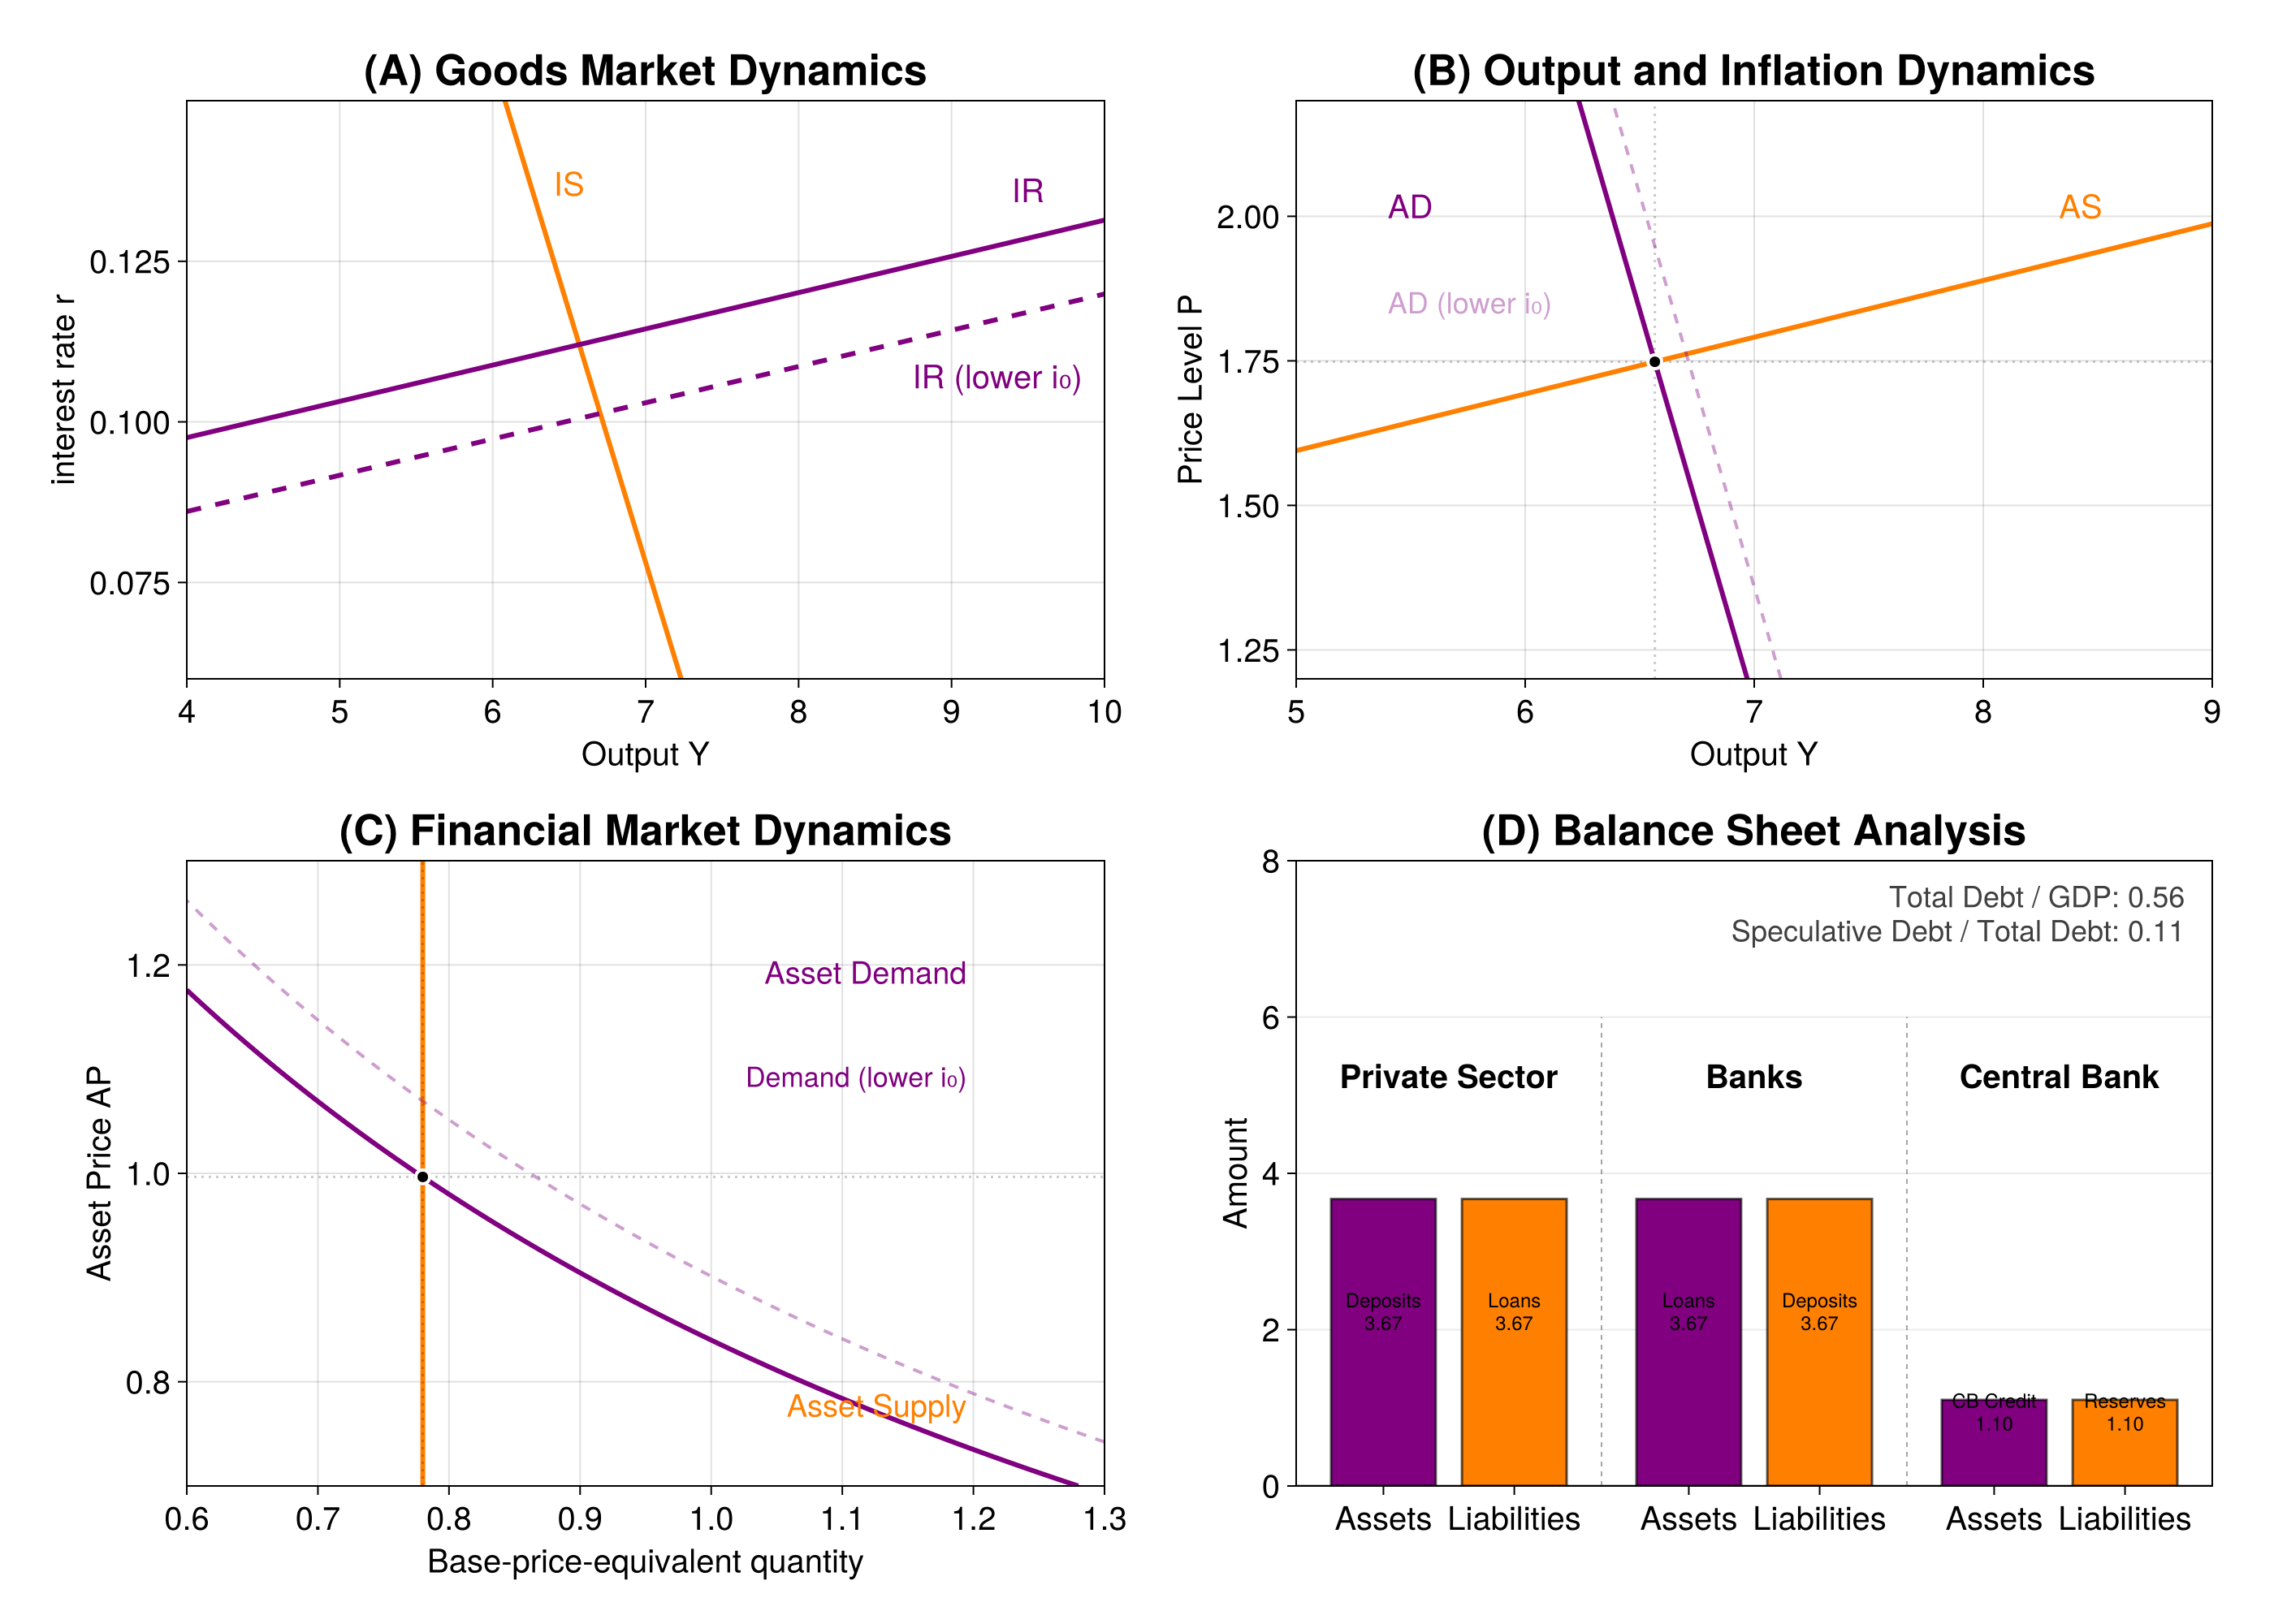

In [8]:
# ── 3. Layout & display ────────────────────────────────────────────────
colgap!(fig.layout, 42)
rowgap!(fig.layout, 22)
rowsize!(fig.layout, 1, Relative(0.48))
rowsize!(fig.layout, 2, Relative(0.52))

fig  # display inline

In [ ]:
# ── 4. Export ───────────────────────────────────────────────────────────
output_dir = normpath(joinpath(@__DIR__, "..", "..", "plots"))
mkpath(output_dir)

pdf_path = joinpath(output_dir, "baseline_mathematica_style.pdf")
png_path = joinpath(output_dir, "baseline_mathematica_style.png")

save(pdf_path, fig; pt_per_unit = 2)
println("Saved: $pdf_path")
save(png_path, fig)
println("Saved: $png_path")

In [ ]:
# ── 5. Verify equilibrium values ────────────────────────────────────────
println("\n── Equilibrium values ──")
for (k, v) in sort!(collect(vars); by = first)
    println(@sprintf("  %12s = %.6f", k, v))
end